In [36]:
import pandas as pd
import seaborn as sns
import pymongo
import os
from dotenv import load_dotenv  # Fixed ty
load_dotenv() 

True

In [37]:
df=pd.read_csv('/Users/anish/Documents/Diabetes/Notebooks/diabetes.csv',sep=';')

In [38]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [39]:
df['id'].value_counts()

id
0        1
1        1
2        1
3        1
4        1
        ..
99993    1
99995    1
99996    1
99998    1
99999    1
Name: count, Length: 70000, dtype: int64

In [40]:
df.drop(columns='id',inplace=True)

In [41]:
df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [42]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  int64  
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  int64  
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  int64  
 5   ap_lo        70000 non-null  int64  
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 6.4 MB


Features:

Age | Objective Feature | age | int (days)

Height | Objective Feature | height | int (cm) |

Weight | Objective Feature | weight | float (kg) |

Gender | Objective Feature | gender | categorical code |

Systolic blood pressure | Examination Feature | ap_hi | int |

Diastolic blood pressure | Examination Feature | ap_lo | int |

Cholesterol | Examination Feature | cholesterol | 1: normal, 2: boderline high , 3: high |

Glucose | Examination Feature | gluc | 1: normal, 2: boderline high, 3: high  |

Smoking | Subjective Feature | smoke | binary |

Alcohol intake | Subjective Feature | alco | binary |

Physical activity | Subjective Feature | active | binary |

Presence or absence of cardiovascular disease | Target Variable | cardio | binary |

In [44]:
df.isnull().sum()


age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [45]:
print(df.columns)

Index(['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')


In [46]:
df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [47]:
df['cholesterol'].value_counts()

cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64

In [48]:
df['active'].value_counts()

active
1    56261
0    13739
Name: count, dtype: int64

In [49]:
cardio_corr=df.corr()['cardio']

In [50]:
cardio_corr

age            0.238159
gender         0.008109
height        -0.010821
weight         0.181660
ap_hi          0.054475
ap_lo          0.065719
cholesterol    0.221147
gluc           0.089307
smoke         -0.015486
alco          -0.007330
active        -0.035653
cardio         1.000000
Name: cardio, dtype: float64

In [51]:
df['ap_hi'].describe()

count    70000.000000
mean       128.817286
std        154.011419
min       -150.000000
25%        120.000000
50%        120.000000
75%        140.000000
max      16020.000000
Name: ap_hi, dtype: float64

In [52]:
df=df[(df['ap_hi']>=80)  & 
                (df['ap_hi']<=220) & 
                (df['ap_lo']>=40)  & 
                (df['ap_lo']<=130) ]

In [53]:
df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [54]:
df['ap_hi'].describe()

count    68692.000000
mean       126.611396
std         16.639269
min         80.000000
25%        120.000000
50%        120.000000
75%        140.000000
max        220.000000
Name: ap_hi, dtype: float64

In [55]:
cardio_corr=df.corr()['cardio']

In [56]:
cardio_corr

age            0.239526
gender         0.007005
height        -0.010884
weight         0.179347
ap_hi          0.427277
ap_lo          0.339112
cholesterol    0.221418
gluc           0.089845
smoke         -0.016352
alco          -0.008712
active        -0.037512
cardio         1.000000
Name: cardio, dtype: float64

In [57]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,68692.0,19464.423776,2468.132150,10798.0,17657.75,19701.0,21324.0,23713.0
gender,68692.0,1.348629,0.476540,1.0,1.00,1.0,2.0,2.0
height,68692.0,164.361294,8.185241,55.0,159.00,165.0,170.0,250.0
weight,68692.0,74.117037,14.327295,11.0,65.00,72.0,82.0,200.0
ap_hi,68692.0,126.611396,16.639269,80.0,120.00,120.0,140.0,220.0
ap_lo,68692.0,81.315626,9.429107,40.0,80.00,80.0,90.0,130.0
cholesterol,68692.0,1.364584,0.678893,1.0,1.00,1.0,1.0,3.0
gluc,68692.0,1.225689,0.571612,1.0,1.00,1.0,1.0,3.0
smoke,68692.0,0.087943,0.283214,0.0,0.00,0.0,0.0,1.0
alco,68692.0,0.053427,0.224885,0.0,0.00,0.0,0.0,1.0


In [58]:
low_height=df['height'].quantile(0.001)
max_height=df['height'].quantile(0.999)
low_weight=df['weight'].quantile(0.001)
max_weight=df['weight'].quantile(0.9999)



df=df[(df["height"]>=low_height) & (df
             ["height"]<=max_height) & (df['weight']>=low_weight) & (df['weight']<=max_weight)]


In [59]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,68525.0,19464.662196,2468.083983,10798.0,17658.0,19701.0,21324.0,23713.0
gender,68525.0,1.348384,0.476462,1.0,1.0,1.0,2.0,2.0
height,68525.0,164.393988,7.854106,120.0,159.0,165.0,170.0,190.0
weight,68525.0,74.114461,14.211932,40.0,65.0,72.0,82.0,178.0
ap_hi,68525.0,126.618227,16.629836,80.0,120.0,120.0,140.0,220.0
ap_lo,68525.0,81.319372,9.422119,40.0,80.0,80.0,90.0,130.0
cholesterol,68525.0,1.364801,0.679004,1.0,1.0,1.0,2.0,3.0
gluc,68525.0,1.225772,0.571670,1.0,1.0,1.0,1.0,3.0
smoke,68525.0,0.087910,0.283165,0.0,0.0,0.0,0.0,1.0
alco,68525.0,0.053338,0.224709,0.0,0.0,0.0,0.0,1.0


In [60]:
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)
df['bmi_category'] =pd.cut(df['bmi'],bins=[0,18.5,25,30,1000],labels=['Underweight','Normal','Overweight','Obese'])

/var/folders/gr/nm7dwh7127g__kjqr5rz6www0000gn/T/ipykernel_2672/912383327.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)
/var/folders/gr/nm7dwh7127g__kjqr5rz6www0000gn/T/ipykernel_2672/912383327.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['bmi_category'] =pd.cut(df['bmi'],bins=[0,18.5,25,30,1000],labels=['Underweight','Normal','Overweight','Obese'])


In [61]:
df.drop(columns='bmi')

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi_category
0,18393,2,168,62.0,110,80,1,1,0,0,1,0,Normal
1,20228,1,156,85.0,140,90,3,1,0,0,1,1,Obese
2,18857,1,165,64.0,130,70,3,1,0,0,0,1,Normal
3,17623,2,169,82.0,150,100,1,1,0,0,1,1,Overweight
4,17474,1,156,56.0,100,60,1,1,0,0,0,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,19240,2,168,76.0,120,80,1,1,1,0,1,0,Overweight
69996,22601,1,158,126.0,140,90,2,2,0,0,1,1,Obese
69997,19066,2,183,105.0,180,90,3,1,0,1,0,1,Obese
69998,22431,1,163,72.0,135,80,1,2,0,0,0,1,Overweight


In [62]:
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']


/var/folders/gr/nm7dwh7127g__kjqr5rz6www0000gn/T/ipykernel_2672/4259792147.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']


In [63]:
data=df[df['cardio']==1]

In [64]:
data

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi,bmi_category,pulse_pressure
1,20228,1,156,85.0,140,90,3,1,0,0,1,1,34.927679,Obese,50
2,18857,1,165,64.0,130,70,3,1,0,0,0,1,23.507805,Normal,60
3,17623,2,169,82.0,150,100,1,1,0,0,1,1,28.710479,Overweight,50
7,22584,2,178,95.0,130,90,3,3,0,0,1,1,29.983588,Overweight,40
15,16782,2,172,112.0,120,80,1,1,0,0,0,1,37.858302,Obese,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69993,19699,1,172,70.0,130,90,1,1,0,0,1,1,23.661439,Normal,40
69994,21074,1,165,80.0,150,80,1,1,0,0,1,1,29.384757,Overweight,70
69996,22601,1,158,126.0,140,90,2,2,0,0,1,1,50.472681,Obese,50
69997,19066,2,183,105.0,180,90,3,1,0,1,0,1,31.353579,Obese,90


<Axes: xlabel='bmi_category', ylabel='Count'>

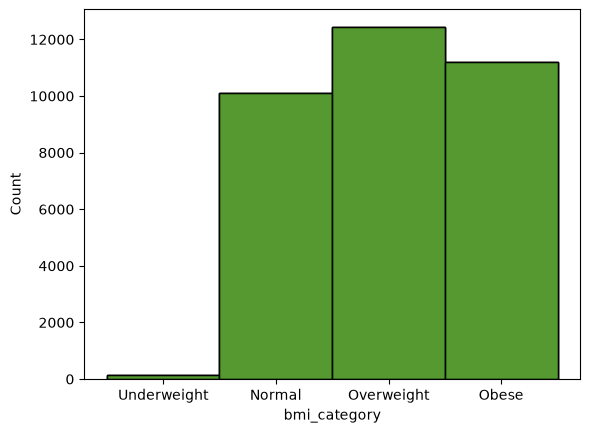

In [65]:
# Option 1 — number of bins
sns.histplot(data=data, x='bmi_category', bins=3)

sns.histplot(data=data, x='bmi_category')

sns.histplot(data=data, x='bmi_category', binwidth=2)


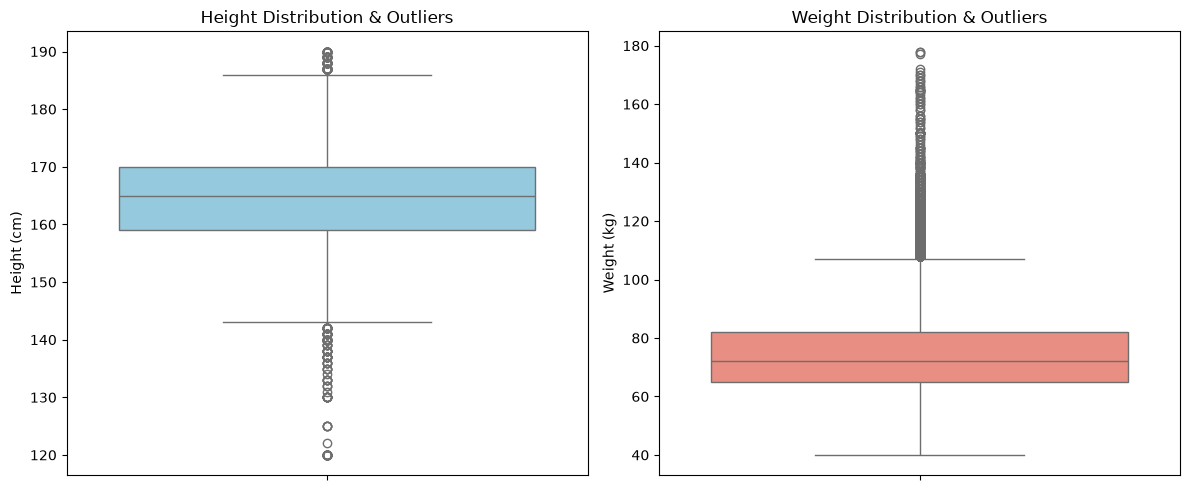

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, y='height', ax=axes[0], color='skyblue')
axes[0].set_title('Height Distribution & Outliers')
axes[0].set_ylabel('Height (cm)')

sns.boxplot(data=df, y='weight', ax=axes[1], color='salmon')
axes[1].set_title('Weight Distribution & Outliers')
axes[1].set_ylabel('Weight (kg)')

plt.tight_layout()
plt.show()

/var/folders/gr/nm7dwh7127g__kjqr5rz6www0000gn/T/ipykernel_2672/3116823068.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='smoke', y='cardio', jitter=0.25, size=4, alpha=0.3, palette='Dark2')


<Axes: xlabel='smoke', ylabel='cardio'>

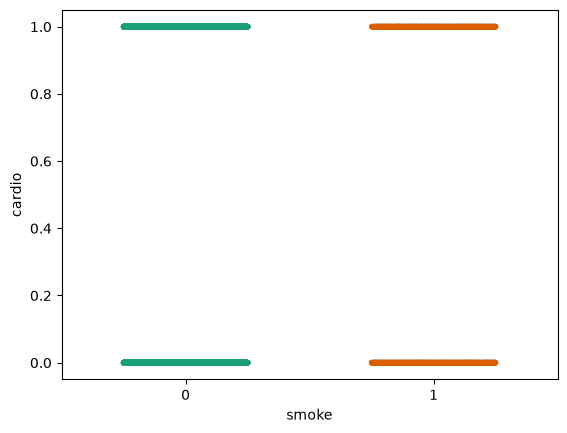

In [67]:
sns.stripplot(data=df, x='smoke', y='cardio', jitter=0.25, size=4, alpha=0.3, palette='Dark2')

In [ ]:
# Create a normalized cross-tabulation table
print(pd.crosstab(df['smoke'], df['cardio'], normalize='index') * 100)

cardio          0          1
smoke                       
0       50.283316  49.716684
1       53.170005  46.829995


In [ ]:
df.groupby(['cardio', 'smoke'])['age'].mean()

cardio  smoke
0       0        51.765421
        1        50.944271
1       0        55.035140
        1        53.733355
Name: age, dtype: float64

/var/folders/gr/nm7dwh7127g__kjqr5rz6www0000gn/T/ipykernel_92756/1645181672.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='gluc', y='cardio', jitter=0.25, size=4, alpha=0.3, palette='Dark2')


<Axes: xlabel='gluc', ylabel='cardio'>

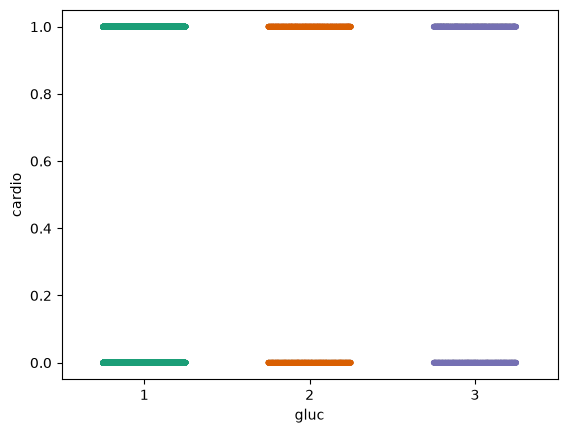

In [ ]:
sns.stripplot(data=df, x='gluc', y='cardio', jitter=0.25, size=4, alpha=0.3, palette='Dark2')

In [ ]:
print(pd.crosstab(df['gluc'], df['cardio']))

cardio      0      1
gluc                
1       30637  27772
2        2085   2978
3        1993   3227


In [ ]:
gluc_cardio_pct = pd.crosstab(df['gluc'], df['cardio'], normalize='index') * 100

Text(0, 0.5, 'proportions')

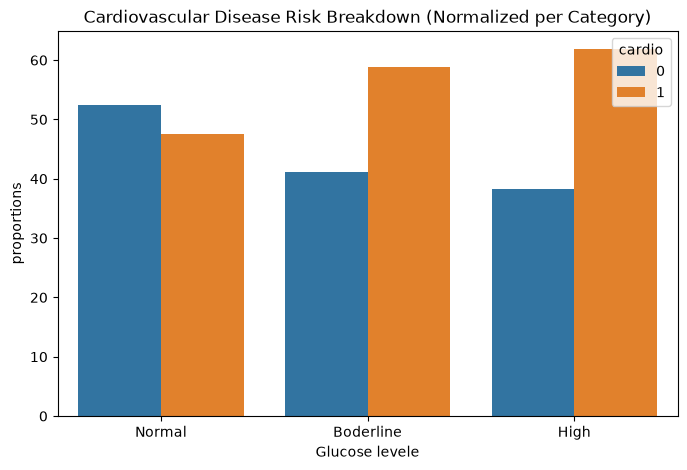

In [ ]:
df_ct=(df.groupby('gluc')['cardio'].value_counts(normalize=True)*100).reset_index()
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_ct,x='gluc',y='proportion',hue='cardio',ax=ax)
ax.set_title('Cardiovascular Disease Risk Breakdown (Normalized per Category)')
ax.set_xticks([0,1,2],labels=['Normal','Boderline','High'])
ax.set_xlabel('Glucose levele')
ax.set_ylabel('proportions')

   smoke  cardio  percentage
0      0       0   50.274396
1      0       1   49.725604
2      1       0   53.220452
3      1       1   46.779548


Text(0, 0.5, 'Percentages')

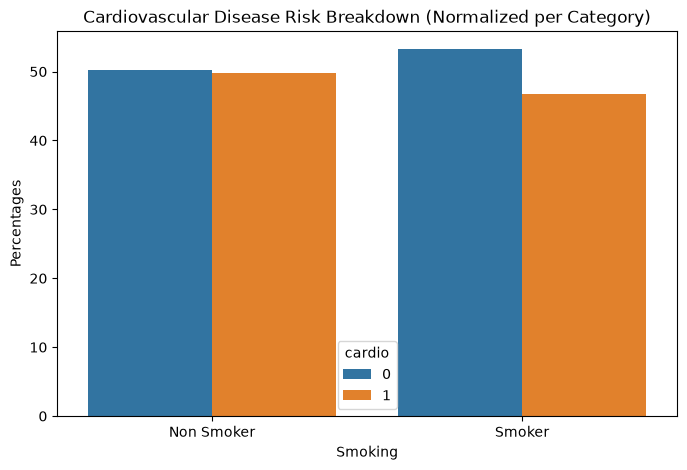

In [ ]:
df_ct = (df.groupby('smoke')['cardio'].value_counts(normalize=True) * 100).reset_index(name='percentage')
print(df_ct)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_ct, x='smoke', y='percentage', hue='cardio', ax=ax)

ax.set_title('Cardiovascular Disease Risk Breakdown (Normalized per Category)')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Non Smoker', 'Smoker'])
ax.set_xlabel('Smoking')
ax.set_ylabel('Percentages')

   alco  cardio  percentage
0     0       0   50.434716
1     0       1   49.565284
2     1       0   52.284542
3     1       1   47.715458


Text(0, 0.5, 'Percentages (%)')

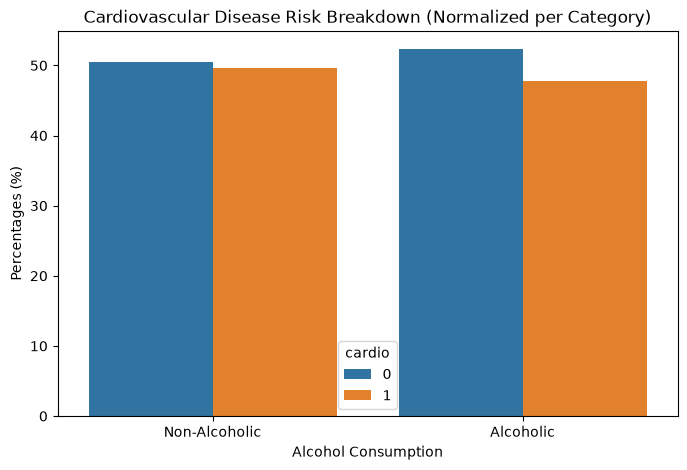

In [ ]:
df_ct = (df.groupby('alco')['cardio'].value_counts(normalize=True) * 100).reset_index(name='percentage')
print(df_ct)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_ct, x='alco', y='percentage', hue='cardio', ax=ax)

ax.set_title('Cardiovascular Disease Risk Breakdown (Normalized per Category)')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Non-Alcoholic', 'Alcoholic'])
ax.set_xlabel('Alcohol Consumption')
ax.set_ylabel('Percentages (%)')

Text(0, 0.5, 'proportions')

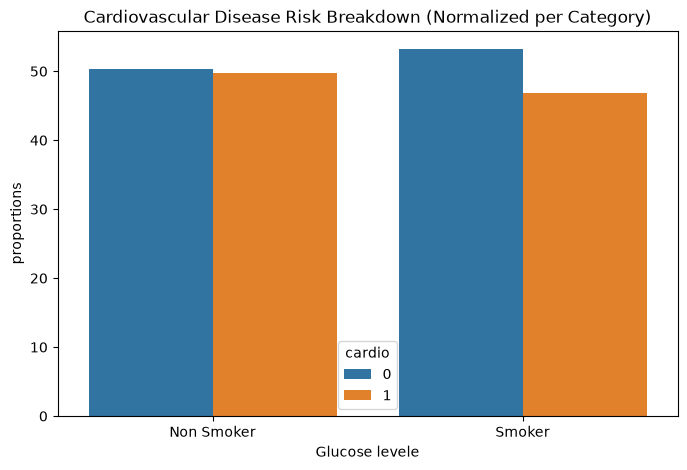

In [ ]:
df_ct=(df.groupby('smoke')['cardio'].value_counts(normalize=True)*100).reset_index()
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_ct,x='smoke',y='proportion',hue='cardio',ax=ax)
ax.set_title('Cardiovascular Disease Risk Breakdown (Normalized per Category)')
ax.set_xticks([0,1],labels=['Non Smoker','Smoker'])
ax.set_xlabel('Glucose levele')
ax.set_ylabel('proportions')

/var/folders/gr/nm7dwh7127g__kjqr5rz6www0000gn/T/ipykernel_92756/36599054.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age_years'] = (df['age'] / 365.25).round().astype(int)


Breakdown for 55-Year-Olds Only:
Empty DataFrame
Columns: []
Index: []


In [ ]:
df

In [ ]:
client=pymongo.MongoClient(os.getenv())
db=client["diabetes_db"]
collection=db["cleaned_data"]